# Applying Random Forest for Classification

This notebook demonstrates a practical application of the Random Forest algorithm for a classification task. We will use the well-known Wine dataset from scikit-learn.

The process will cover:
1.  Loading and exploring the dataset.
2.  Splitting the data into training and testing sets.
3.  Training a Random Forest Classifier.
4.  Evaluating the model's performance.
5.  Visualizing the importance of each feature.

### Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_wine

### Load and Explore the Dataset

We will use the Wine dataset, which has 13 features (chemical properties) and 3 classes of wine.

In [18]:
# Load the dataset
wine_data = load_wine()

# Create a pandas DataFrame for easier manipulation
features_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
target_df = pd.DataFrame(wine_data.target, columns=["target"])

# Combine features and target into a single DataFrame
wine_df = pd.concat([features_df, target_df], axis=1)

# Display the first 5 rows of the dataset
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [19]:
# Get a summary of the dataset
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [20]:
# Check for missing values
wine_df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

### Prepare Data for Modeling

We will separate the features (X) from the target variable (y).

In [21]:
# Define features (X) and target (y)
X = wine_data.data
y = wine_data.target

# Print the shape of X and y
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (178, 13)
Shape of target (y): (178,)


### Split Data into Training and Testing Sets

We'll split the data into 80% for training and 20% for testing to evaluate the model's performance on unseen data.

In [22]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% of the data will be used for testing
    random_state=42,  # Ensures reproducibility of the split
    stratify=y,  # Ensures the proportion of classes is the same in train and test sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 142 samples
Testing set size: 36 samples


### Train the Random Forest Model

Now we create an instance of the `RandomForestClassifier` and train it with our training data.

- `n_estimators`: The number of trees in the forest.
- `random_state`: A seed for reproducibility of results.

The **Out-of-Bag (OOB) score** is an internal performance evaluation method for ensemble models like Random Forest that use bootstrap aggregating (bagging). It functions as a built-in cross-validation, providing an unbiased estimate of the model's accuracy on unseen data.

**How it works:**
* Each tree in the forest is trained on a random bootstrap sample (about 2/3) of the training data. The remaining 1/3 of the data is its "Out-of-Bag" sample.
* To get a prediction for any given data point, it is passed through all the trees that did **not** use it for training.
* The final OOB score is the accuracy (or other metric) calculated from these predictions across all data points.

**Key benefit:** It provides a reliable estimate of test performance without the need to create a separate validation set or run a costly cross-validation process.

In [23]:
# Create a Random Forest Classifier instance
random_forest_model = RandomForestClassifier(
    n_estimators=100, random_state=42, oob_score=True
)

# Train the model using the training data
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

### Evaluate the Model

We'll now make predictions on the test set and evaluate the model's performance using accuracy, a confusion matrix, and a classification report.

In [24]:
# Make predictions on the test data
y_predictions = random_forest_model.predict(X_test)

# Calculate the model accuracy
accuracy = accuracy_score(y_test, y_predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# We can also check the Out-of-Bag (OOB) score, which is an internal estimate of performance
oob_score = random_forest_model.oob_score_
print(f"Out-of-Bag Score: {oob_score * 100:.2f}%")

Model Accuracy: 100.00%
Out-of-Bag Score: 97.89%


Text(0.5, 1.0, 'Confusion Matrix')

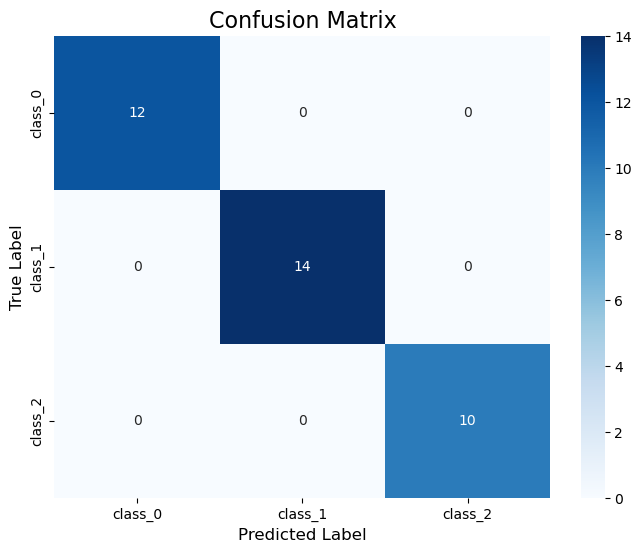

In [25]:
# Display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine_data.target_names,
    yticklabels=wine_data.target_names,
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=16)

In [26]:
# Display the classification report
class_report = classification_report(
    y_test, y_predictions, target_names=wine_data.target_names
)

print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Feature Importance

A great benefit of Random Forest is that it provides a measure of feature importance. This tells us which features were most influential in the model's predictions.

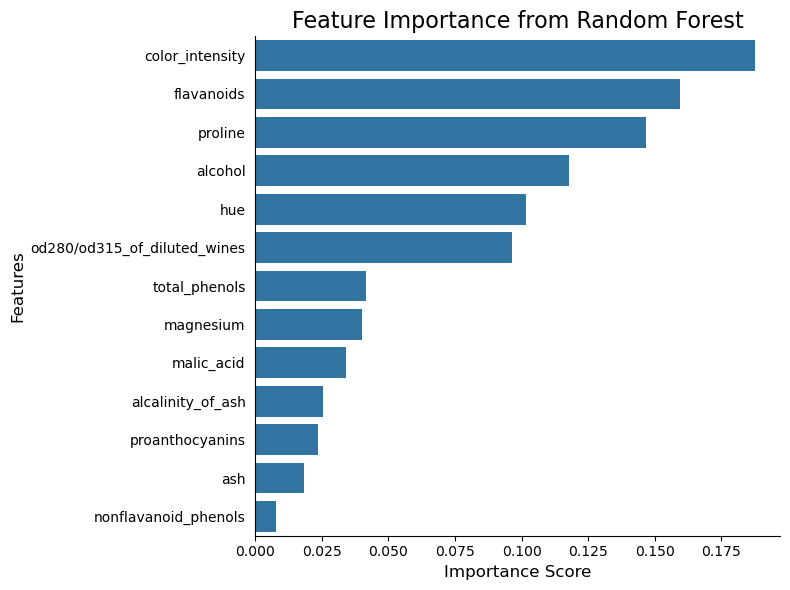

In [27]:
# Get feature importances from the trained model
feature_importances = random_forest_model.feature_importances_
feature_names = wine_data.feature_names

# Create a DataFrame for better visualization
importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importances}
)

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot the feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance from Random Forest", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", left=False)
plt.tight_layout()